## EXO1 :

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = pd.read_csv('./data/Mall_Customers.csv')
X = data.iloc[:, [3, 4]].values

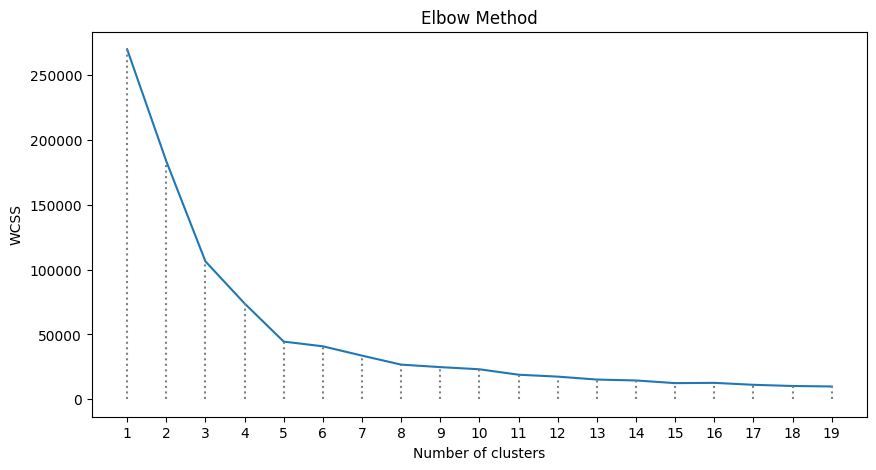

In [11]:
wcss = []
for i in range(1, 20):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10,5))
plt.plot(range(1, 20), wcss)
plt.vlines(range(1, 20),0, wcss, linestyle="dotted", color="gray")
plt.xticks(range(1, 20))
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [13]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

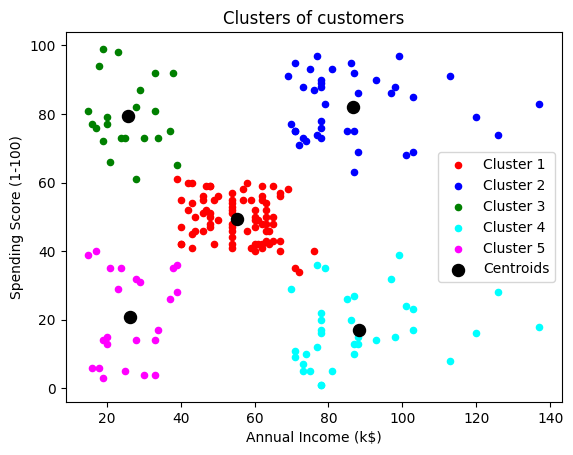

In [19]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 20, c = 'red',
label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 20, c = 'blue',
label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 20, c = 'green',
label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 20, c = 'cyan',
label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 20, c = 'magenta',
label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
s = 75, c = 'black', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## EXO2 :

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler

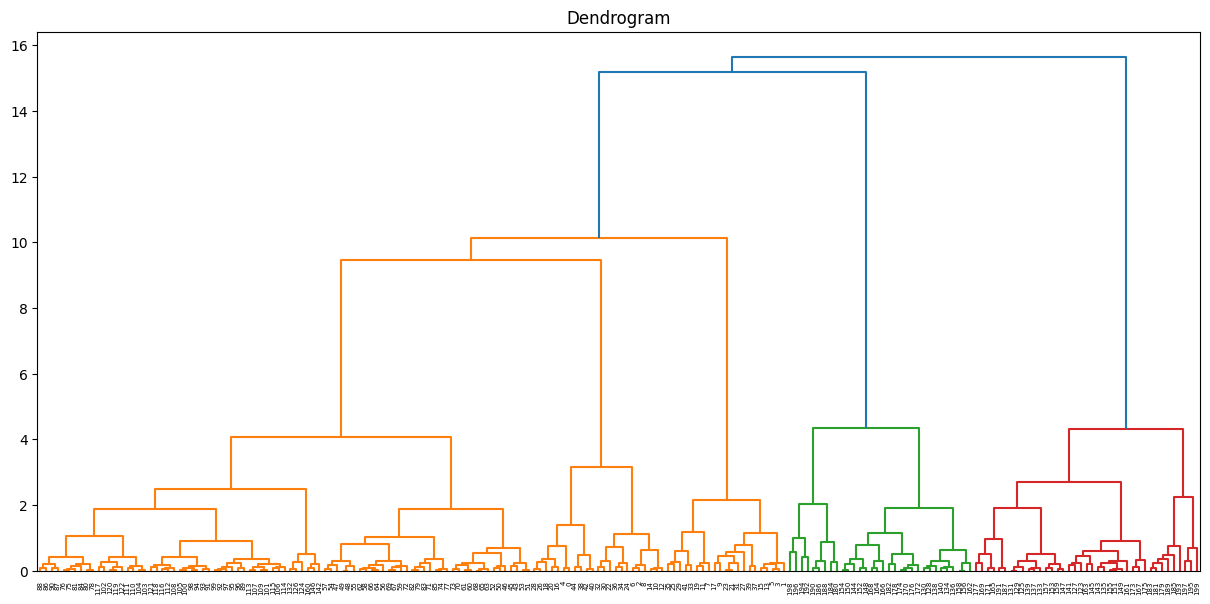

In [23]:
X_scaled = StandardScaler().fit_transform(X) 

Z = linkage(X_scaled, method='ward') 

plt.figure(figsize=(15, 7))
plt.title("Dendrogram")
dendrogram(
    Z,
    orientation='top',
    distance_sort='descending',
    show_leaf_counts=True
)
plt.show()


In [ ]:
from sklearn.cluster import AgglomerativeClustering

optimal_clusters = 5
hca_model = AgglomerativeClustering(n_clusters=optimal_clusters, metric='euclidean', linkage='ward')
cluster_labels = hca_model.fit_predict(X_scaled)

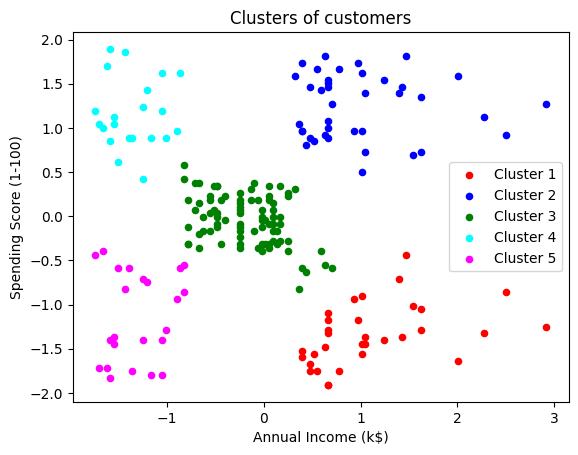

In [25]:
plt.scatter(X_scaled[cluster_labels == 0, 0], X_scaled[cluster_labels == 0, 1], s = 20, c = 'red',
label = 'Cluster 1')
plt.scatter(X_scaled[cluster_labels == 1, 0], X_scaled[cluster_labels == 1, 1], s = 20, c = 'blue',
label = 'Cluster 2')
plt.scatter(X_scaled[cluster_labels == 2, 0], X_scaled[cluster_labels == 2, 1], s = 20, c = 'green',
label = 'Cluster 3')
plt.scatter(X_scaled[cluster_labels == 3, 0], X_scaled[cluster_labels == 3, 1], s = 20, c = 'cyan',
label = 'Cluster 4')
plt.scatter(X_scaled[cluster_labels == 4, 0], X_scaled[cluster_labels == 4, 1], s = 20, c = 'magenta',
label = 'Cluster 5')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()